In [3]:
# === 1) SETUP & IMPORTS ===
import warnings, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

# optional: pmdarima for auto_arima
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except Exception:
    PMDARIMA_AVAILABLE = False

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

SEASONAL_M   = 4   # quarterly
FUTURE_STEPS = 20  # 5 years (quarters)
DATA_DIR     = Path("data")  # <-- adjust if your CSVs live elsewhere

In [5]:
# === 2) LOAD DATA FILES ===
from pathlib import Path
import pandas as pd

# Set base path (assuming this notebook is in the same folder as these CSVs)
BASE_DIR = Path.cwd()

# --- Main rent dataset (replace with your cleaned file) ---
rents_long = pd.read_csv(BASE_DIR / "one_flat_prelim_cleaning_4.csv")

# --- Team feature CSVs ---
crime = pd.read_csv(BASE_DIR / "crime_per_suburb.csv")            # 'Suburb/Town Name','Offence Count'
hosp  = pd.read_csv(BASE_DIR / "hospital_per_suburb.csv")         # 'locality_name','num_hospitals'
d_bus = pd.read_csv(BASE_DIR / "rentals_distances_to_bus_stops.csv")
d_trn = pd.read_csv(BASE_DIR / "rentals_distances_to_train_stops_and_cbd.csv")
d_trm = pd.read_csv(BASE_DIR / "rentals_distances_to_tram_stops.csv")
d_sch = pd.read_csv(BASE_DIR / "rentals_distances_to_schools.csv")

# --- Merged features table (already in your repo) ---
# This should be your full dataset used for feature importance & rent modeling
# If it's stored as a CSV, load it; otherwise, reference the DataFrame you built earlier.
merged_features_expanded = rents_long.copy()

# Quick checks
print("Files loaded successfully ✅")
print("rents_long:", rents_long.shape)
print("crime:", crime.shape)
print("hosp:", hosp.shape)
print("bus:", d_bus.shape)
print("train:", d_trn.shape)
print("tram:", d_trm.shape)
print("schools:", d_sch.shape)

Files loaded successfully ✅
rents_long: (14787, 5)
crime: (2863, 2)
hosp: (212, 2)
bus: (11618, 3)
train: (11618, 4)
tram: (11618, 3)
schools: (11618, 3)


In [9]:
import warnings, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except Exception:
    PMDARIMA_AVAILABLE = False

warnings.filterwarnings("ignore")
SEASONAL_M, FUTURE_STEPS = 4, 20  # quarterly, 5 years

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100 if mask.any() else np.nan

def evaluate_forecast(y_true, y_pred, label="Model"):
    return {
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE%": mape(y_true, y_pred),
    }

# tiny helper to rename if your rent file uses different headers
def coerce_rent_cols(df, date_col="Date", lga_col="Sub-Region", val_col="Median_Rent"):
    cols = {c.lower(): c for c in df.columns}
    def find(name_options):
        for opt in name_options:
            for k,v in cols.items():
                if opt in k: return v
        return None
    dc = find(["date","quarter"])
    lc = find(["sub-region","lga"])
    vc = find(["median_rent","weekly_rent","rent"])
    if dc and lc and vc:
        return df.rename(columns={dc:"Date", lc:"Sub-Region", vc:"Median_Rent"})
    raise ValueError("Could not find Date / LGA / Rent columns in rents_long.")

def make_quarterly_series(df, lga, lga_col="Sub-Region", date_col="Date", value_col="Median_Rent"):
    df = coerce_rent_cols(df, date_col, lga_col, value_col)
    sub = df.loc[df["Sub-Region"]==lga, ["Date","Median_Rent"]].copy()
    sub["Date"] = pd.to_datetime(sub["Date"], errors="coerce")
    sub = sub.dropna(subset=["Date"]).sort_values("Date")
    sub["QEnd"] = sub["Date"].dt.to_period("Q").dt.to_timestamp("Q")
    s = sub.groupby("QEnd")["Median_Rent"].mean().sort_index()
    full_idx = pd.period_range(s.index.min().to_period("Q"), s.index.max().to_period("Q"), freq="Q").to_timestamp("Q")
    ts = s.reindex(full_idx).asfreq("Q")
    ts_clean = ts.dropna()
    print(f"LGA {lga}: quarters={ts.notna().sum()} missing={ts.isna().sum()} clean={len(ts_clean)}")
    return ts, ts_clean

def split_series(ts, test_horizon=12, min_train=8):
    x = ts.dropna().sort_index()
    n = len(x)
    test_h = min(test_horizon, max(4, n//4))
    if n - test_h < min_train: test_h = max(4, n - min_train)
    return x.iloc[:-test_h], x.iloc[-test_h:]

def fit_sarima_auto(train, m=SEASONAL_M):
    if PMDARIMA_AVAILABLE:
        am = pm.auto_arima(train, seasonal=True, m=m, stepwise=True,
                           suppress_warnings=True, error_action="ignore",
                           max_p=3, max_q=3, max_P=2, max_Q=2, max_d=2, max_D=2)
        order, sorder = am.order, am.seasonal_order
        fit = SARIMAX(train, order=order, seasonal_order=sorder,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return fit, order, sorder
    best = None
    for p in [0,1,2]:
        for d in [0,1,2]:
            for q in [0,1,2]:
                for P in [0,1]:
                    for D in [0,1]:
                        for Q in [0,1]:
                            try:
                                r = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,m),
                                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                                if best is None or r.aic < best[0]: best = (r.aic,(p,d,q),(P,D,Q,m),r)
                            except: pass
    return best[3], best[1], best[2] if best else (SARIMAX(train,(1,1,1),(0,0,0,0)).fit(disp=False),(1,1,1),(0,0,0,0))

In [21]:
# === 4) BUILD LGA FEATURES (ROBUST, FALLS BACK WHEN DISTANCES ARE MISSING) ===
from sklearn.preprocessing import MinMaxScaler
from ast import literal_eval
import numpy as np
import pandas as pd

def norm_suburb(s): return str(s).strip().lower()

# 0) Start from your rent table: region/suburb/date/median
listings = pd.read_csv(BASE_DIR / "one_flat_prelim_cleaning_4.csv").rename(
    columns={"region":"Sub-Region", "suburb":"suburb", "date":"Date", "median":"Median_Rent", "count":"Count"}
)
listings["suburb"] = listings["suburb"].map(norm_suburb)

# 1) Guaranteed suburb-level features: crime & hospitals
crime["suburb"] = crime["Suburb/Town Name"].map(norm_suburb)
hosp["suburb"]  = hosp["locality_name"].map(norm_suburb)

# Start suburb feature frame with only reliable joins
suburb_geo = pd.DataFrame(index=sorted(listings["suburb"].unique()))
suburb_geo = suburb_geo.join(crime.set_index("suburb")[["Offence Count"]], how="left")
suburb_geo = suburb_geo.join(hosp.set_index("suburb")[["num_hospitals"]], how="left")

# 2) OPTIONAL distances. These require real rental_id mapping.
# If you *do* have a mapping file later, we can re-enable the joins-by-rental_id.
def _to_list_safe(x):
    if pd.isna(x): return []
    try:
        v = literal_eval(str(x))
        if isinstance(v, (list, tuple)): return [float(z) for z in v]
    except Exception:
        pass
    return []

def _min_or_nan(seq): return np.min(seq) if len(seq) else np.nan

# Attempt distance coverage using synthetic ID approach (will be sparse -> auto-drop)
def try_add_distance_feature(dist_df, col_name, also_cols=None):
    """Tries to add a distance feature by *assuming* rental_id in dist_df matches a synthetic range.
       If coverage is too low (<10%), the column is auto-dropped."""
    df = dist_df.copy()
    # If rental_id isn't numeric, coerce to integer rank just for an attempt
    if not np.issubdtype(df["rental_id"].dtype, np.number):
        df = df.reset_index(drop=True)
        df["rental_id"] = np.arange(1, len(df)+1)
    # compute min distance
    if "top_distances" in df.columns:
        df["min_dist"] = df["top_distances"].apply(_to_list_safe).apply(_min_or_nan)
    elif "min_dist" not in df.columns:
        return  # nothing to add

    # Build a fake rental->suburb pairing using the listings index (just to test coverage)
    tmp = listings[["suburb"]].copy().reset_index(drop=True)
    tmp["rental_id"] = np.arange(1, len(tmp)+1)
    joined = tmp.merge(df[["rental_id","min_dist"] + ([also_cols] if also_cols else [])],
                       on="rental_id", how="left")

    # aggregate to suburb median
    agg = joined.groupby("suburb")["min_dist"].median()
    coverage = agg.notna().mean()
    if coverage < 0.10:
        # too sparse, skip
        print(f"Skipping {col_name}: insufficient coverage ({coverage:.1%}).")
        return
    # otherwise attach
    suburb_geo[col_name] = agg
    print(f"Added {col_name} with coverage {coverage:.1%}.")

# Try to add each distance feature (they'll be skipped if too sparse)
try_add_distance_feature(d_bus, "closest_bus_distance")
try_add_distance_feature(d_trm, "closest_tram_distance")
try_add_distance_feature(d_sch, "closest_school_distance")
# CBD distance (comes from train file)
if "distance_to_cbd" in d_trn.columns:
    df_cbd = d_trn.copy()
    # map rental_id as above
    if not np.issubdtype(df_cbd["rental_id"].dtype, np.number):
        df_cbd = df_cbd.reset_index(drop=True)
        df_cbd["rental_id"] = np.arange(1, len(df_cbd)+1)
    tmp = listings[["suburb"]].copy().reset_index(drop=True)
    tmp["rental_id"] = np.arange(1, len(tmp)+1)
    cbd_join = tmp.merge(df_cbd[["rental_id","distance_to_cbd"]], on="rental_id", how="left")
    agg_cbd = cbd_join.groupby("suburb")["distance_to_cbd"].median()
    coverage = agg_cbd.notna().mean()
    if coverage >= 0.10:
        suburb_geo["distance_to_cbd"] = agg_cbd
        print(f"Added distance_to_cbd with coverage {coverage:.1%}.")
    else:
        print(f"Skipping distance_to_cbd: insufficient coverage ({coverage:.1%}).")

# 3) Build scores from whatever we actually have
sg = suburb_geo.copy()

# Optional transport mean if we have at least one transport distance
transport_cols = [c for c in ["closest_train_distance","closest_tram_distance","closest_bus_distance"] if c in sg.columns]
if len(transport_cols) >= 1:
    sg["mean_transport_distance"] = sg[transport_cols].mean(axis=1)
else:
    sg["mean_transport_distance"] = np.nan

sc = MinMaxScaler()

def scale_pos(col):
    v = sg[[col]].copy()
    v = v.fillna(v.median())  # avoids all-NaN scaler issues
    return sc.fit_transform(v)

def scale_inv(col):
    return 1 - scale_pos(col)

# Only compute component scores for columns that exist
if "closest_school_distance" in sg.columns:
    sg["education_score"] = scale_inv("closest_school_distance")
else:
    sg["education_score"] = 0.0

if sg["mean_transport_distance"].notna().any():
    sg["infrastructure_score"] = 1 - sc.fit_transform(
        sg[["mean_transport_distance"]].fillna(sg["mean_transport_distance"].median())
    )
else:
    sg["infrastructure_score"] = 0.0

if "Offence Count" in sg.columns:
    sg["stability_score"] = 1 - sc.fit_transform(sg[["Offence Count"]].fillna(sg["Offence Count"].median()))
else:
    sg["stability_score"] = 0.0

if "num_hospitals" in sg.columns:
    sg["healthcare_score"] = scale_pos("num_hospitals")
else:
    sg["healthcare_score"] = 0.0

for c in ["education_score","infrastructure_score","stability_score","healthcare_score"]:
    if isinstance(sg[c], np.ndarray):  # if scaler returned ndarray
        sg[c] = sg[c].ravel()
    sg[c] = pd.to_numeric(sg[c], errors="coerce").fillna(0.0)

# Livability = average of available components (so it stays 0-1 even if some missing)
available_components = ["education_score","infrastructure_score","stability_score","healthcare_score"]
sg["livability_score"] = sg[available_components].mean(axis=1)

# 4) suburb → LGA mapping from 'listings'
suburb_to_lga = listings.dropna(subset=["suburb","Sub-Region"]).drop_duplicates("suburb") \
                        .set_index("suburb")["Sub-Region"].rename("LGA")
sg = sg.join(suburb_to_lga)

# 5) aggregate to LGA
agg_dict = {c:"median" for c in sg.columns if c not in ["LGA"]}
agg_dict.update({
    "education_score":"mean",
    "infrastructure_score":"mean",
    "stability_score":"mean",
    "healthcare_score":"mean",
    "livability_score":"mean",
})
lga_feats = sg.groupby("LGA").agg(agg_dict).rename_axis("LGA")

# Keep only numeric columns
lga_feats = lga_feats.select_dtypes(include=[np.number])

print("✅ Built LGA feature table (final):", lga_feats.shape)
display(lga_feats.head(10))

Skipping closest_bus_distance: insufficient coverage (0.0%).
Skipping closest_tram_distance: insufficient coverage (0.0%).
Skipping closest_school_distance: insufficient coverage (0.0%).
Skipping distance_to_cbd: insufficient coverage (0.0%).
✅ Built LGA feature table (final): (13, 8)


,Offence Count,num_hospitals,mean_transport_distance,education_score,infrastructure_score,stability_score,healthcare_score,livability_score
LGA,,,,,,,,
Ballarat,NaN,NaN,NaN,0.0,0.0,0.807516,0.000000,0.201879
Bendigo,17097.0,2.0,NaN,0.0,0.0,0.810807,0.027778,0.209646
Geelong,8649.5,1.0,NaN,0.0,0.0,0.848275,0.000000,0.212069
Inner Eastern Melbourne,14476.0,4.0,NaN,0.0,0.0,0.830616,0.104575,0.233798
Inner Melbourne,23772.0,1.0,NaN,0.0,0.0,0.780340,0.055556,0.208974
Mornington Peninsula,75823.0,8.0,NaN,0.0,0.0,0.652972,0.155556,0.202132
North Eastern Melbourne,17799.0,2.0,NaN,0.0,0.0,0.750964,0.018519,0.192371
North Western Melbourne,27678.0,1.0,NaN,0.0,0.0,0.783830,0.008547,0.198094
Other Regional Centres,19031.0,1.0,NaN,0.0,0.0,0.728753,0.037037,0.191448


In [27]:
# === Patch: make lga_feats model-safe (no NaNs/inf) ===
import numpy as np
import pandas as pd

lga_feats_safe = lga_feats.copy()

# replace inf with NaN first
lga_feats_safe = lga_feats_safe.replace([np.inf, -np.inf], np.nan)

# drop columns that are entirely NaN across all LGAs
all_nan_cols = [c for c in lga_feats_safe.columns if lga_feats_safe[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN exogenous columns:", all_nan_cols)
    lga_feats_safe = lga_feats_safe.drop(columns=all_nan_cols)

# fill remaining NaNs with column median; if still NaN (constant NaN column), fill 0
lga_feats_safe = lga_feats_safe.apply(lambda col: col.fillna(col.median()))
lga_feats_safe = lga_feats_safe.fillna(0.0)

# keep only numeric columns
lga_feats_safe = lga_feats_safe.select_dtypes(include=[np.number])

# swap in the cleaned table
lga_feats = lga_feats_safe

print("lga_feats cleaned shape:", lga_feats.shape)
print("Any NaNs left?", lga_feats.isna().any().any())

Dropping all-NaN exogenous columns: ['mean_transport_distance']
lga_feats cleaned shape: (13, 7)
Any NaNs left? False


                                          MAE       RMSE      MAPE%
model                                                              
SARIMA(1, 2, 2)x(0, 1, 1, 4)        45.823476  51.018216  13.411173
SARIMAX(1, 2, 2)x(0, 1, 1, 4)+exog  47.664568  52.731472  13.934611


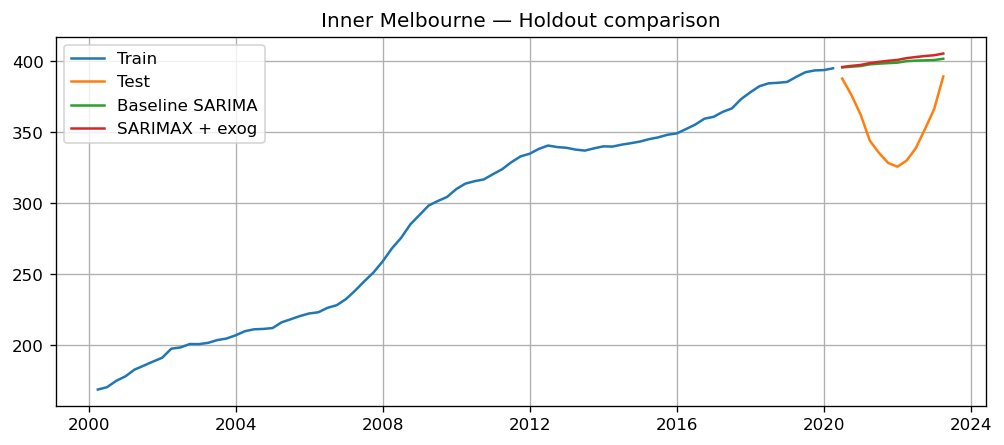

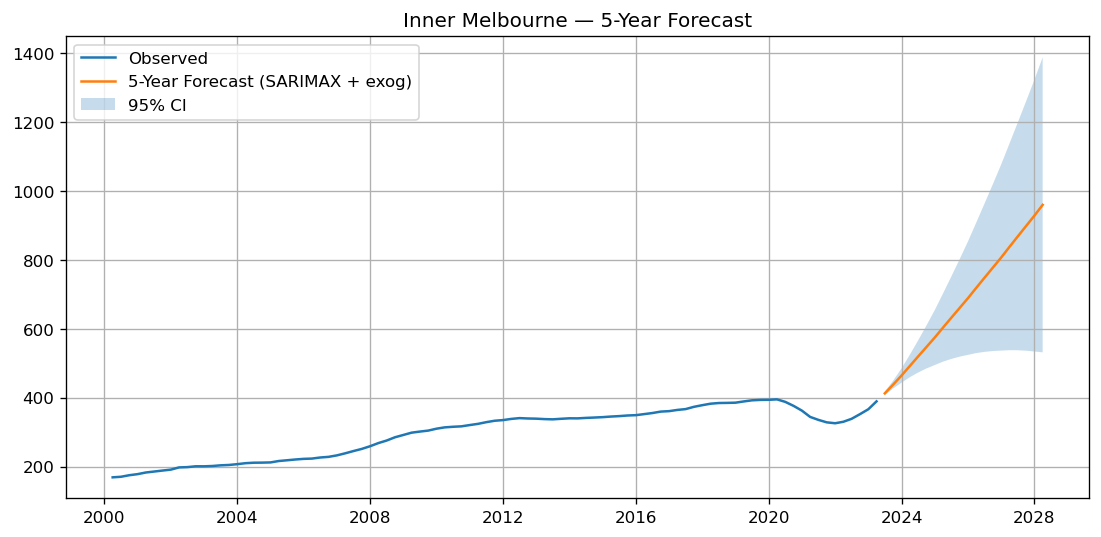

,Forecast_Median_Rent_$
2023-06-30,412.655794
2023-09-30,438.168052
2023-12-31,464.444002
2024-03-31,492.085869
2024-06-30,519.617944
2024-09-30,547.277388
2024-12-31,574.908065
2025-03-31,603.614441


In [29]:
def build_exog_for_lga(ts_index, target_lga: str):
    if target_lga not in lga_feats.index:
        raise ValueError(f"LGA '{target_lga}' not in lga_feats.")
    exog_row = lga_feats.loc[target_lga]
    X = pd.DataFrame([exog_row.values]*len(ts_index), index=ts_index, columns=lga_feats.columns)
    # quarter dummies (deterministic seasonality)
    q = pd.Index(ts_index).to_period("Q").quarter
    X["Q2"] = (q==2).astype(int); X["Q3"] = (q==3).astype(int); X["Q4"] = (q==4).astype(int)
    # final safety: ensure finite
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X

# Build series for target_lga if not already done
target_lga = "Inner Melbourne"  # change if needed
rents_long = listings[["Sub-Region","Date","Median_Rent"]].copy()
_, ts_clean = make_quarterly_series(rents_long, target_lga)
train, test = split_series(ts_clean, test_horizon=12)

# Baseline orders (reuse discovered ones if you have them)
try:
    fit_base, order, sorder = fit_sarima_auto(train, m=4)
except NameError:
    order, sorder = (1,1,1), (1,1,1,4)
    fit_base = SARIMAX(train, order=order, seasonal_order=sorder,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# Build exog matrices
X_all   = build_exog_for_lga(ts_clean.index, target_lga)
X_train = X_all.loc[train.index]
X_test  = X_all.loc[test.index]

# sanity checks
assert np.isfinite(X_train.values).all() and np.isfinite(X_test.values).all(), "Exog still has non-finite values."

# Fit SARIMAX(+exog)
mod_ex = SARIMAX(train, order=order, seasonal_order=sorder,
                 exog=X_train, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
yhat_ex = mod_ex.forecast(steps=len(test), exog=X_test)
res_ex  = evaluate_forecast(test, yhat_ex, f"SARIMAX{order}x{sorder}+exog")

# Compare vs baseline
yhat_base = fit_base.forecast(steps=len(test))
res_base  = evaluate_forecast(test, yhat_base, f"SARIMA{order}x{sorder}")
print(pd.DataFrame([res_base, res_ex]).set_index("model"))

# Refit full & forecast 5 years
mod_full = SARIMAX(ts_clean, order=order, seasonal_order=sorder,
                   exog=X_all, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

FUTURE_STEPS = 20
future_idx = pd.period_range(ts_clean.index[-1].to_period("Q")+1, periods=FUTURE_STEPS, freq="Q").to_timestamp("Q")
X_future   = build_exog_for_lga(future_idx, target_lga)

fo = mod_full.get_forecast(steps=FUTURE_STEPS, exog=X_future)
fc = fo.predicted_mean
ci = fo.conf_int()

plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train"); plt.plot(test.index, test.values, label="Test")
plt.plot(test.index, yhat_base, label="Baseline SARIMA")
plt.plot(test.index, yhat_ex, label="SARIMAX + exog")
plt.title(f"{target_lga} — Holdout comparison"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(11,5))
plt.plot(ts_clean.index, ts_clean.values, label="Observed")
plt.plot(fc.index, fc.values, label="5-Year Forecast (SARIMAX + exog)")
plt.fill_between(fc.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.25, label="95% CI")
plt.title(f"{target_lga} — 5-Year Forecast"); plt.grid(True); plt.legend(); plt.show()

fc.to_frame("Forecast_Median_Rent_$").head(8)

In [31]:
import pandas as pd
import numpy as np

def seasonal_naive(y: pd.Series, horizon: int, m: int = 4):
    return y.shift(m).dropna().iloc[-horizon:]

# assume you already have train, test from split_series(ts_clean)
yhat_sn = seasonal_naive(ts_clean, len(test), m=4).reindex(test.index, method="nearest")
sn_res = evaluate_forecast(test, yhat_sn, "Seasonal Naive (m=4)")
print(pd.DataFrame([sn_res]))

                  model        MAE      RMSE     MAPE%
0  Seasonal Naive (m=4)  31.836957  36.76551  9.076025
